In [ ]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


1. Scalars, vectors, matrices & tensors

1A. THE FOUR CONTAINERS

In [ ]:
import numpy as np
scalar = np.array(5)
vector = np.array([2, 5, 1])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 2, 2))


for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


1B. TENSOR OPERATIONS: add, transpose, reshape

In [ ]:
import numpy as np
A = np.arange(6).reshape(2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


LAB EXERCISE 1 — Tensor ops: add, transpose, reshape

1. ndim and shape

In [ ]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

print(T.ndim)
print(T.shape)


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
2
(3, 4)


2. T + T

In [ ]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

print(T + T)


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]


3. Transpose (print .T.shape) and reshape to (2, 6)

In [ ]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

print(T.T.shape)
print(T.reshape(2, 6))


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
(4, 3)
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


2. Dot & cross products, and norms

2A. DOT & CROSS PRODUCTS

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])


print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


2B. NORMS (vector length) + COSINE SIMILARITY

In [ ]:
print('L2 norm  ||a||_2 :', la.norm(a))
print('L1 norm  ||a||_1 :', la.norm(a, 1))
print('Linf norm        :', la.norm(a, np.inf))


def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs

1. L1 and L2 norm of u

In [ ]:
import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),
    (np.array([1, 2, 3]), np.array([3, 2, 1])),
    (np.array([2, 0, 0]), np.array([0, 5, 0])),
]

for i, (u, v) in enumerate(pairs, start=1):
    l1 = np.linalg.norm(u, ord=1)
    l2 = np.linalg.norm(u)
    cosine = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    print("Pair", i)
    print("L1 norm:", l1)
    print("L2 norm:", l2)
    print("Cosine similarity:", cosine)


Pair 1
L1 norm: 2.0
L2 norm: 1.4142135623730951
Cosine similarity: 0.9999999999999998
Pair 2
L1 norm: 6.0
L2 norm: 3.7416573867739413
Cosine similarity: 0.7142857142857143
Pair 3
L1 norm: 2.0
L2 norm: 2.0
Cosine similarity: 0.0


2. cosine similarity of u and v

In [ ]:
import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),
    (np.array([1, 2, 3]), np.array([3, 2, 1])),
    (np.array([2, 0, 0]), np.array([0, 5, 0])),
]

similarities = []

for u, v in pairs:
    cosine = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    similarities.append(cosine)

print("Most similar pair:", np.argmax(similarities) + 1)


Most similar pair: 1


3. Most similar pair = pair1

3. Matrix operations & special matrices

3A. CORE MATRIX OPERATIONS

In [ ]:
A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


3B. SPECIAL MATRICES: identity, symmetric, orthogonal

In [ ]:
I = np.eye(2)
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))


print('A symmetric?', np.allclose(A, A.T))


theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


LAB EXERCISE 3 — Inverse, trace, and matrix tests

1. Inverse and trace of M


In [ ]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])

print(np.linalg.inv(M))
print(np.trace(M))


[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
7.0


2. M @ inv(M) == I ?


In [ ]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])

print(np.allclose(M @ np.linalg.inv(M), np.eye(2)))


True


3. Is M symmetric? Is P orthogonal?


In [ ]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])

print(np.allclose(M, M.T))
print(np.allclose(P.T @ P, np.eye(2)))


True
True


4. Transformations: rotation & scaling

4A. BUILD TRANSFORMATION MATRICES

In [ ]:
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)


S = np.array([[1.5, 0.0],
              [0.0, 0.5]])


t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


4B. PLOT ORIGINAL vs TRANSFORMED

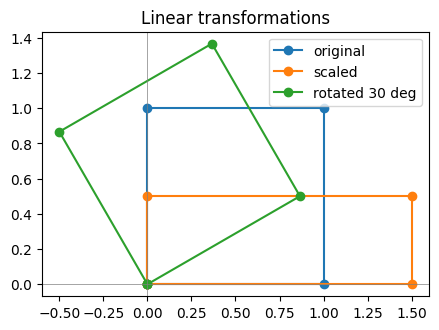

In [ ]:
def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

LAB EXERCISE 4 — Apply 2 transformations & plot

1. Scaling matrix

In [ ]:
import numpy as np

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

S = np.array([[2, 0],
              [0, 0.5]])

print(S)


[[2.  0. ]
 [0.  0.5]]


2. Rotation matrix (45 degrees)


In [ ]:
import numpy as np

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

print(R)


[[ 0.707 -0.707]
 [ 0.707  0.707]]


3. Apply both transformations and plots


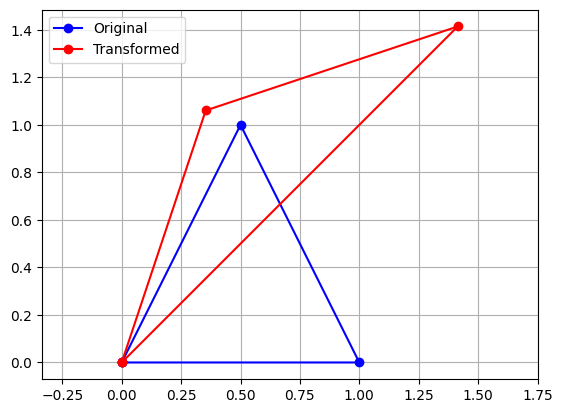

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

S = np.array([[2, 0],
              [0, 0.5]])

theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

transformed = R @ S @ tri

plt.plot(np.append(tri[0], tri[0, 0]),
         np.append(tri[1], tri[1, 0]), 'bo-', label='Original')

plt.plot(np.append(transformed[0], transformed[0, 0]),
         np.append(transformed[1], transformed[1, 0]), 'ro-', label='Transformed')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


5. Eigenvalues & eigenvectors

5A. COMPUTE EIGENVALUES & EIGENVECTORS

In [ ]:
A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)


Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


5B. VERIFY  A v = lambda v

In [ ]:
import numpy as np
import scipy.linalg as la

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)

print('Eigenvalues:', vals)
print('Eigenvectors:\n', vecs)

for i in range(len(vals)):
    v = vecs[:, i]
    lhs = A @ v
    rhs = vals[i] * v
    print(f'lambda={vals[i].real:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


Eigenvalues: [2.+0.j 3.+0.j]
Eigenvectors:
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


LAB EXERCISE 5 — Eigenvalues/vectors & verification

1. Eigenvalues and Eigenvectors


In [ ]:
import numpy as np
import scipy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

vals, vecs = la.eig(C)


2. Print Eigenvalues

In [ ]:
print('Eigenvalues:', vals)


Eigenvalues: [5.+0.j 2.+0.j]


3. Verify A v = λv for the First Eigenvector
v

In [ ]:
v = vecs[:, 0]
lhs = C @ v
rhs = vals[0] * v

print('A v:', lhs)
print('lambda v:', rhs)
print('A v == lambda v?', np.allclose(lhs, rhs))


A v: [3.536 3.536]
lambda v: [3.536+0.j 3.536+0.j]
A v == lambda v? True


6. Rank, solving systems & cosine similarity

6A. SOLVE A 3x3 SYSTEM  A x = b

In [ ]:
import numpy as np
import scipy.linalg as la

A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])

b = np.array([8., -11., -3.])

x = la.solve(A, b)

print('Solution x:', x)
print('Rank of A:', np.linalg.matrix_rank(A))
print('Full rank -> a unique solution exists')


Solution x: [ 2.  3. -1.]
Rank of A: 3
Full rank -> a unique solution exists


6B. RANK TELLS YOU SOLVABILITY

In [ ]:
import numpy as np
import scipy.linalg as la

D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])

print('Rank of D:', np.linalg.matrix_rank(D), '-> < 3, so rows are dependent')


Rank of D: 2 -> < 3, so rows are dependent


6C. COSINE SIMILARITY ON 'EMBEDDINGS

In [ ]:
import numpy as np

king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))


cosine(king, queen): 0.986
cosine(king, apple): 0.267


LAB EXERCISE 6 — Solve a system + compare embeddings

1. Solve A2 x = b2


In [ ]:
import numpy as np
import scipy.linalg as la

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

x2 = la.solve(A2, b2)

print('Solution x:', x2)


Solution x: [1. 2.]


2. Rank of A2


In [ ]:
print('Rank of A2:', np.linalg.matrix_rank(A2))


Rank of A2: 2


In [ ]:
3. Cosine Similarity


In [ ]:
cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

cos_cat_dog = np.dot(cat, dog) / (np.linalg.norm(cat) * np.linalg.norm(dog))
cos_cat_car = np.dot(cat, car) / (np.linalg.norm(cat) * np.linalg.norm(car))

print('Cosine(cat, dog):', cos_cat_dog)
print('Cosine(cat, car):', cos_cat_car)

if cos_cat_dog > cos_cat_car:
    print('Cat and dog are more similar')
else:
    print('Cat and car are more similar')


Cosine(cat, dog): 0.9946195449838785
Cosine(cat, car): 0.29255678516966266
Cat and dog are more similar
